# E-Commerce Sales and Customer Segmentation Analysis Using Python

This project analyses e-commerce transactions to understand sales performance, product demand, geographic contribution, and customer behaviour. It combines exploratory data analysis with RFM (Recency, Frequency, Monetary) analysis and K-Means clustering to create practical customer segments from the actual Online Retail dataset.

## 1. Import Libraries

The analysis uses pandas and NumPy for data work, matplotlib and seaborn for visualisation, and scikit-learn for scaling and K-Means clustering.

In [44]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")

## 2. Load Dataset

The dataset is loaded from the same folder as this notebook. The loader tries UTF-8 first and falls back to a common Western encoding if needed.

In [45]:
data_path = Path("OnlineRetail.csv")

try:
    df_raw = pd.read_csv(data_path, encoding="utf-8")
except UnicodeDecodeError:
    df_raw = pd.read_csv(data_path, encoding="ISO-8859-1")

print("First 5 rows:")
display(df_raw.head())
print(f"\nRows and columns: {df_raw.shape}")
print("Column names:")
print(df_raw.columns.tolist())

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom



Rows and columns: (541909, 8)
Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


## 3. Dataset Understanding

This section reviews structure, data types, missingness, and duplicated records before any transformations are applied.

In [46]:
print("Dataset information:")
df_raw.info()

print("\nData types:")
display(df_raw.dtypes.rename("dtype").to_frame())

print("Missing values by column:")
display(df_raw.isna().sum().rename("missing_values").to_frame())

print(f"Duplicate rows: {df_raw.duplicated().sum():,}")

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Data types:


,dtype
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


Missing values by column:


,missing_values
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Duplicate rows: 5,268


## 4. Data Cleaning

Duplicate records are removed. Customer-level analysis requires a known CustomerID, while rows without a product description cannot support product analysis. Cancelled invoices are identified from InvoiceNo values beginning with `C` and excluded from sales metrics. Quantity, UnitPrice, and InvoiceDate are converted to analysis-ready types, and Revenue is calculated from the transaction quantity and unit price.

In [47]:
df = df_raw.copy()
df = df.drop_duplicates().copy()

# Keep the cancellation flag for traceability before excluding cancellations.
df["InvoiceNo"] = df["InvoiceNo"].astype(str).str.strip()
df["is_cancelled"] = df["InvoiceNo"].str.startswith("C")
cancelled_count = int(df["is_cancelled"].sum())

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce")

# Remove rows that cannot support reliable sales or customer calculations.
df = df.dropna(subset=["InvoiceDate", "Quantity", "UnitPrice", "Description"])
df = df[~df["is_cancelled"]].copy()
df = df[df["CustomerID"].notna()].copy()
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] >= 0)].copy()
df["CustomerID"] = df["CustomerID"].astype(int).astype(str)
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(f"Cancelled invoices identified: {cancelled_count:,}")
print(f"Cleaned dataset shape: {df.shape}")
display(df.head())

Cancelled invoices identified: 9,251
Cleaned dataset shape: (392732, 10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34


## 5. Basic Sales Summary

The following measures describe the cleaned, non-cancelled transaction set.

In [48]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["Description"].nunique()

sales_summary = pd.DataFrame({
    "Metric": ["Total Revenue", "Total Orders", "Total Customers", "Total Unique Products"],
    "Value": [total_revenue, total_orders, total_customers, total_products],
})
sales_summary.loc[sales_summary["Metric"] == "Total Revenue", "Value"] = sales_summary.loc[
    sales_summary["Metric"] == "Total Revenue", "Value"
].map(lambda value: f"£{value:,.2f}")
display(sales_summary)

,Metric,Value
0,Total Revenue,"£8,887,208.89"
1,Total Orders,"18,536.00"
2,Total Customers,"4,339.00"
3,Total Unique Products,"3,877.00"


## 6. Monthly Sales Analysis

Monthly revenue is calculated from InvoiceDate. The chart and the short interpretation below are generated from the observed monthly values.

,Revenue
Month,
2010-12,"570,422.73"
2011-01,"568,101.31"
2011-02,"446,084.92"
2011-03,"594,081.76"
2011-04,"468,374.33"
2011-05,"677,355.15"
2011-06,"660,046.05"
2011-07,"598,962.90"
2011-08,"644,051.04"


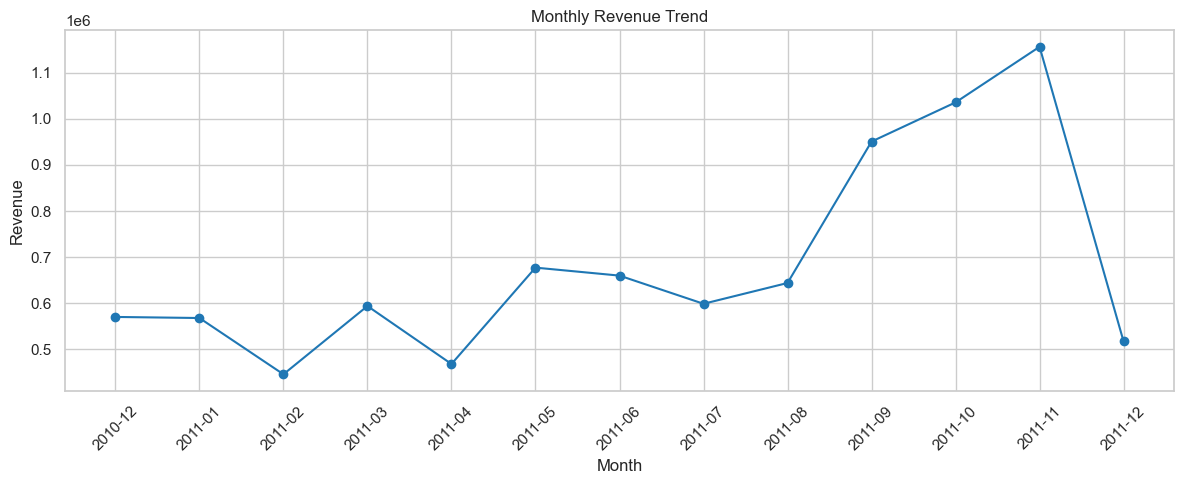

Observed monthly revenue was highest in 2011-11 (£1,156,205.61) and lowest in 2011-02 (£446,084.92).


In [49]:
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("Month")["Revenue"].sum().sort_index()

display(monthly_sales.rename("Revenue").to_frame())

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o", color="#1f77b4")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

peak_month = monthly_sales.idxmax()
low_month = monthly_sales.idxmin()
print(
    f"Observed monthly revenue was highest in {peak_month} (£{monthly_sales.max():,.2f}) "
    f"and lowest in {low_month} (£{monthly_sales.min():,.2f})."
)

## 7. Product Sales Analysis

Products are ranked by their observed total revenue. The top-ten table and chart are computed from the cleaned transactions.

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE","168,469.60"
REGENCY CAKESTAND 3 TIER,"142,264.75"
WHITE HANGING HEART T-LIGHT HOLDER,"100,392.10"
JUMBO BAG RED RETROSPOT,"85,040.54"
MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73"
POSTAGE,"77,803.96"
PARTY BUNTING,"68,785.23"
ASSORTED COLOUR BIRD ORNAMENT,"56,413.03"
Manual,"53,419.93"


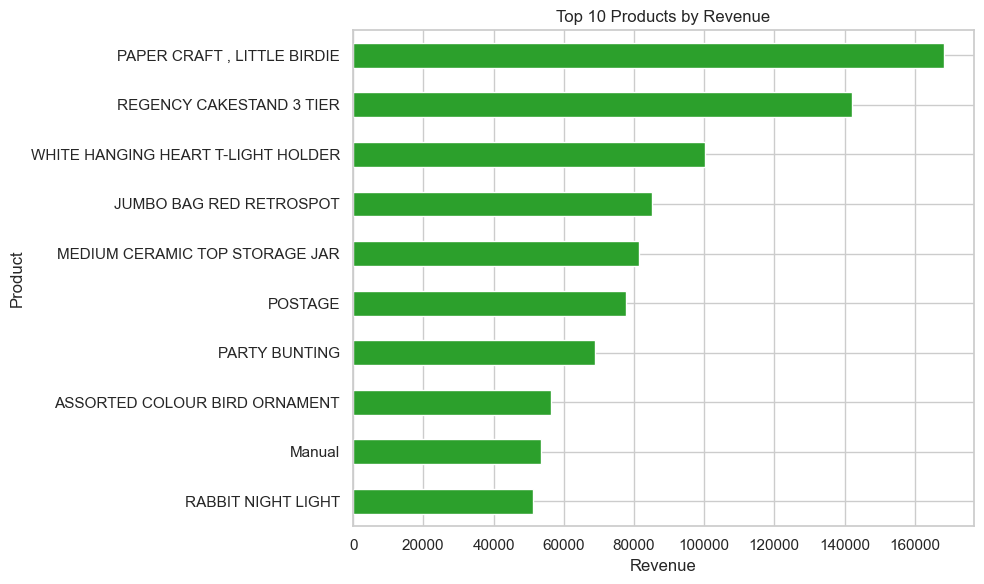

PAPER CRAFT , LITTLE BIRDIE generated the highest product revenue (£168,469.60) in the cleaned data.


In [50]:
product_sales = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False)
top_products = product_sales.head(10).sort_values()

display(product_sales.head(10).rename("Revenue").to_frame())

plt.figure(figsize=(10, 6))
top_products.plot(kind="barh", color="#2ca02c")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

print(
    f"{product_sales.index[0]} generated the highest product revenue "
    f"(£{product_sales.iloc[0]:,.2f}) in the cleaned data."
)

## 8. Country-Wise Sales Analysis

Country totals show where the cleaned dataset generated the most revenue.

,Revenue
Country,
United Kingdom,"7,285,024.64"
Netherlands,"285,446.34"
EIRE,"265,262.46"
Germany,"228,678.40"
France,"208,934.31"
Australia,"138,453.81"
Spain,"61,558.56"
Switzerland,"56,443.95"
Belgium,"41,196.34"


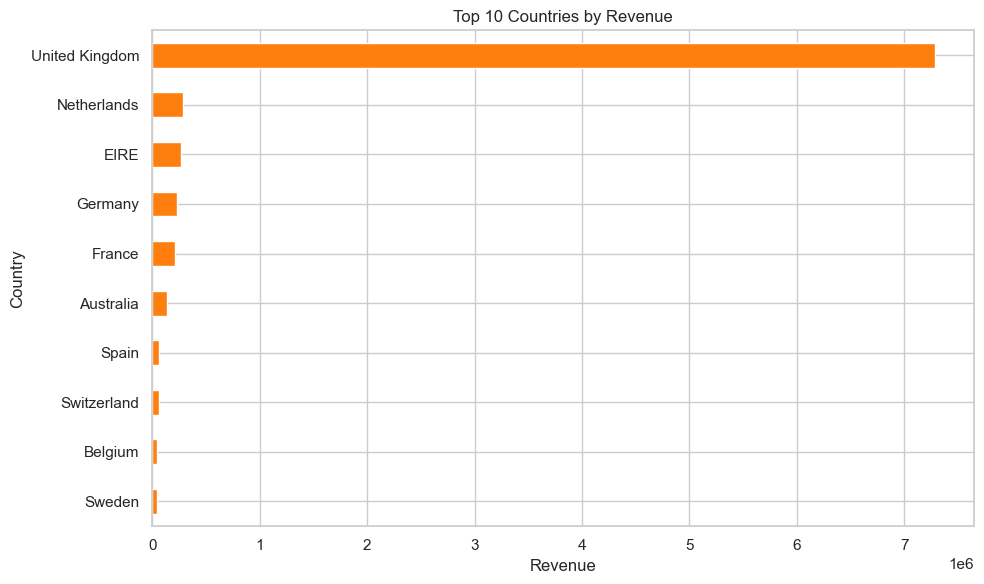

United Kingdom contributed the highest country revenue (£7,285,024.64) in the cleaned data.


In [51]:
country_sales = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
top_countries = country_sales.head(10).sort_values()

display(country_sales.head(10).rename("Revenue").to_frame())

plt.figure(figsize=(10, 6))
top_countries.plot(kind="barh", color="#ff7f0e")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

print(
    f"{country_sales.index[0]} contributed the highest country revenue "
    f"(£{country_sales.iloc[0]:,.2f}) in the cleaned data."
)

## 9. Customer Analysis

Customer-level order and revenue measures identify the most valuable customers in the cleaned data.

Orders per customer:


,Orders
CustomerID,
12748,210
14911,201
17841,124
13089,97
14606,93
15311,91
12971,86
14646,74
16029,63


Top 10 customers by revenue:


,Orders,Revenue
CustomerID,,
14646,74,"280,206.02"
18102,60,"259,657.30"
17450,46,"194,390.79"
16446,2,"168,472.50"
14911,201,"143,711.17"
12415,21,"124,914.53"
14156,55,"117,210.08"
17511,31,"91,062.38"
16029,63,"80,850.84"


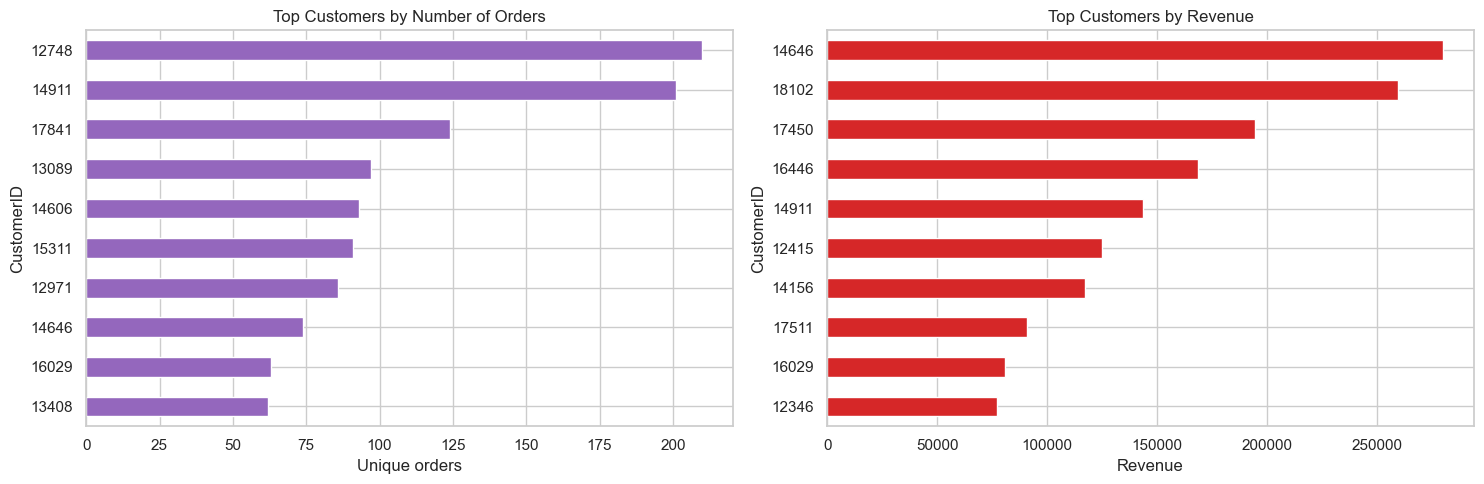

In [52]:
customer_orders = df.groupby("CustomerID")["InvoiceNo"].nunique().sort_values(ascending=False)
customer_revenue = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False)
customer_summary = pd.DataFrame({
    "Orders": customer_orders,
    "Revenue": customer_revenue,
}).sort_values("Revenue", ascending=False)

print("Orders per customer:")
display(customer_orders.rename("Orders").head(10).to_frame())
print("Top 10 customers by revenue:")
display(customer_summary.head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
customer_orders.head(10).sort_values().plot(kind="barh", ax=axes[0], color="#9467bd")
axes[0].set_title("Top Customers by Number of Orders")
axes[0].set_xlabel("Unique orders")
customer_revenue.head(10).sort_values().plot(kind="barh", ax=axes[1], color="#d62728")
axes[1].set_title("Top Customers by Revenue")
axes[1].set_xlabel("Revenue")
plt.tight_layout()
plt.show()

## 10. RFM Analysis

RFM summarises customer behaviour at customer level:

- **Recency:** days since the customer's most recent purchase.
- **Frequency:** number of unique invoices/orders made by the customer.
- **Monetary:** total revenue generated by the customer.

The latest transaction date in the cleaned dataset is used as the reference date, so recency is calculated from the observed data rather than from an invented current date.

In [53]:
reference_date = df["InvoiceDate"].max()
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda dates: (reference_date - dates.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
).reset_index()

print(f"Reference date: {reference_date:%Y-%m-%d %H:%M}")
print(f"RFM customers: {len(rfm):,}")
display(rfm.head())

Reference date: 2011-12-09 12:50
RFM customers: 4,339


,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,"77,183.60"
1,12347,1,7,"4,310.00"
2,12348,74,4,"1,797.24"
3,12349,18,1,"1,757.55"
4,12350,309,1,334.40


## 11. RFM Preparation

RFM variables are usually right-skewed because a small number of customers may purchase much more often or spend much more than the typical customer. A log transformation reduces the influence of extreme values while preserving ordering, and StandardScaler places the three features on a comparable scale before clustering.

In [54]:
rfm_features = rfm[["Recency", "Frequency", "Monetary"]].copy()
rfm_log = np.log1p(rfm_features)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features.columns, index=rfm.index)

print("Scaled RFM feature sample:")
display(rfm_scaled_df.head())

Scaled RFM feature sample:


,Recency,Frequency,Monetary
0,1.41,-0.96,3.70
1,-2.15,1.07,1.41
2,0.38,0.39,0.72
3,-0.57,-0.96,0.70
4,1.37,-0.96,-0.61


## 12. K-Means Customer Segmentation

The elbow method compares within-cluster sum of squares across candidate cluster counts. The selected count is the first point where the improvement becomes relatively small, based on the observed elbow scores.

,Clusters,Inertia
0,2,"6,513.65"
1,3,"4,906.01"
2,4,"4,001.28"
3,5,"3,386.55"
4,6,"2,910.30"
5,7,"2,614.55"
6,8,"2,393.90"
7,9,"2,213.65"
8,10,"2,048.64"


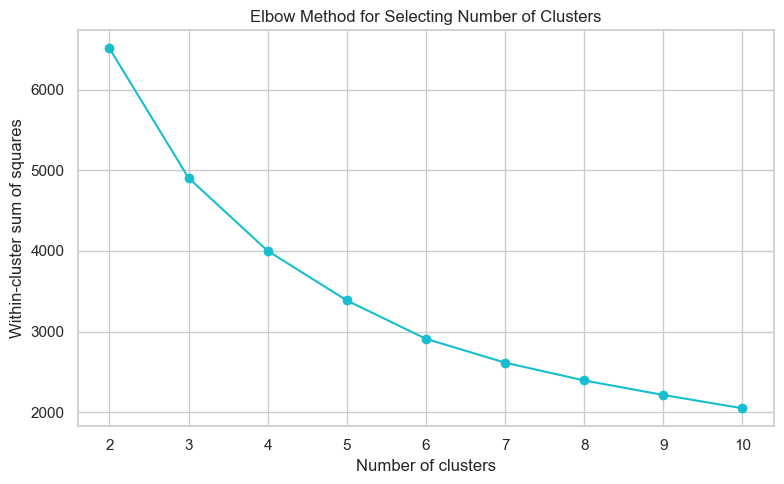

Selected cluster count from the observed elbow scores: 3


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,325,1,"77,183.60",2
1,12347,1,7,"4,310.00",0
2,12348,74,4,"1,797.24",2
3,12349,18,1,"1,757.55",2
4,12350,309,1,334.40,1


In [55]:
max_clusters = min(10, len(rfm_scaled_df) - 1)
cluster_range = range(2, max_clusters + 1)
inertia_values = []

for cluster_count in cluster_range:
    model = KMeans(n_clusters=cluster_count, random_state=42, n_init=10)
    model.fit(rfm_scaled_df)
    inertia_values.append(model.inertia_)

elbow_scores = pd.DataFrame({"Clusters": list(cluster_range), "Inertia": inertia_values})
display(elbow_scores)

plt.figure(figsize=(8, 5))
plt.plot(elbow_scores["Clusters"], elbow_scores["Inertia"], marker="o", color="#17becf")
plt.title("Elbow Method for Selecting Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Within-cluster sum of squares")
plt.xticks(list(cluster_range))
plt.tight_layout()
plt.show()

# Use the largest relative inertia improvement as a reproducible elbow heuristic.
relative_improvement = -elbow_scores["Inertia"].diff() / elbow_scores["Inertia"].shift(1)
if relative_improvement.iloc[1:].notna().any():
    elbow_position = relative_improvement.iloc[1:].idxmax()
    selected_clusters = int(elbow_scores.loc[elbow_position, "Clusters"])
else:
    selected_clusters = int(elbow_scores.iloc[0]["Clusters"])

print(f"Selected cluster count from the observed elbow scores: {selected_clusters}")

kmeans = KMeans(n_clusters=selected_clusters, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled_df)
display(rfm.head())

## 13. Customer Segment Analysis

The summary below describes each cluster using its actual average RFM values. Cluster numbers are identifiers, not business labels; interpretations should be based on the displayed values.

,Average_Recency,Average_Frequency,Average_Monetary,Customers
Cluster,,,,
0,12.93,13.67,"8,016.79",729
1,161.14,1.34,352.00,1922
2,46.19,3.55,"1,401.91",1688


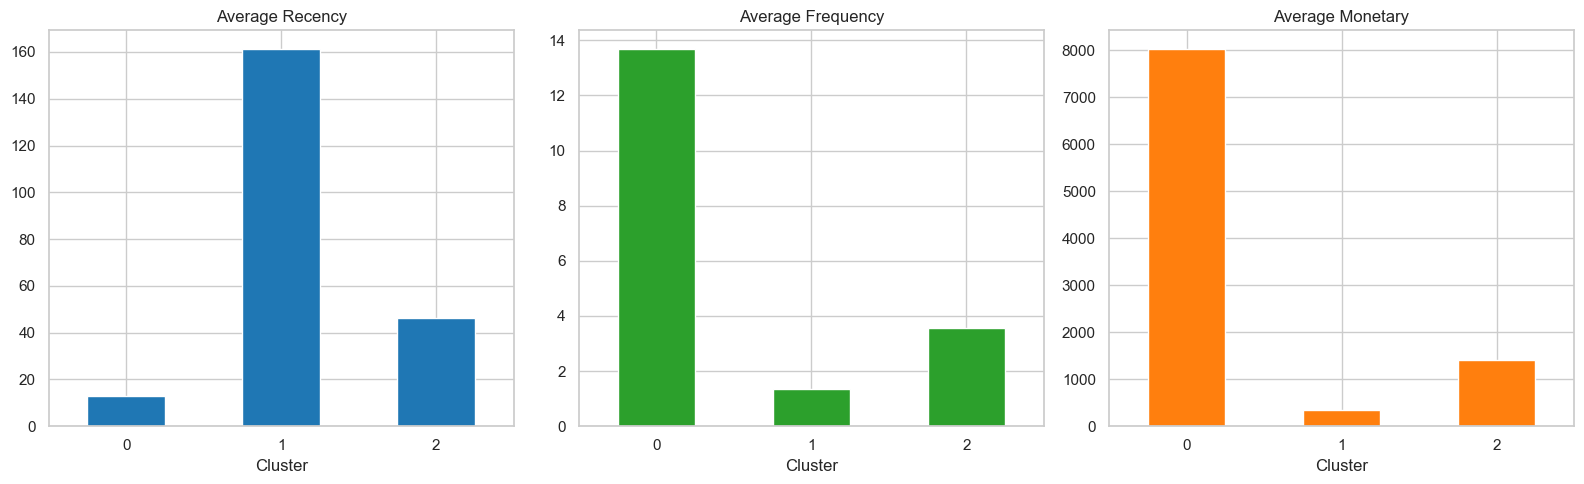

Cluster 0: 729 customers, average recency 12.9 days, average frequency 13.7 orders, average monetary value £8,016.79.
Cluster 1: 1,922 customers, average recency 161.1 days, average frequency 1.3 orders, average monetary value £352.00.
Cluster 2: 1,688 customers, average recency 46.2 days, average frequency 3.5 orders, average monetary value £1,401.91.


In [56]:
cluster_summary = rfm.groupby("Cluster").agg(
    Average_Recency=("Recency", "mean"),
    Average_Frequency=("Frequency", "mean"),
    Average_Monetary=("Monetary", "mean"),
    Customers=("CustomerID", "count"),
).sort_index()

display(cluster_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cluster_summary["Average_Recency"].plot(kind="bar", ax=axes[0], color="#1f77b4", title="Average Recency")
cluster_summary["Average_Frequency"].plot(kind="bar", ax=axes[1], color="#2ca02c", title="Average Frequency")
cluster_summary["Average_Monetary"].plot(kind="bar", ax=axes[2], color="#ff7f0e", title="Average Monetary")
for axis in axes:
    axis.set_xlabel("Cluster")
    axis.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

for cluster_id, values in cluster_summary.iterrows():
    print(
        f"Cluster {cluster_id}: {int(values['Customers']):,} customers, "
        f"average recency {values['Average_Recency']:.1f} days, "
        f"average frequency {values['Average_Frequency']:.1f} orders, "
        f"average monetary value £{values['Average_Monetary']:,.2f}."
    )

## 14. AI/ML Explanation: K-Means Customer Segmentation

K-Means is an **unsupervised machine learning algorithm** that groups observations with similar characteristics. In this project, Recency, Frequency, and Monetary features are used as the input variables. The features are log-transformed to reduce skewness and then standardised with `StandardScaler` so that no feature dominates only because of its scale. K-Means assigns each customer to the nearest learned centroid, producing clusters that represent different observed customer behaviour patterns. These clusters describe the current dataset; they do not predict future sales.

## 15. Key Business Insights

The next cell creates concise, data-driven observations from the calculated tables. Values are inserted from the analysis objects at execution time, so the insights remain tied to the actual dataset.

In [57]:
highest_revenue_cluster = cluster_summary["Average_Monetary"].idxmax()
most_recent_cluster = cluster_summary["Average_Recency"].idxmin()
most_frequent_cluster = cluster_summary["Average_Frequency"].idxmax()

insights = [
    f"Monthly behaviour: revenue peaks in {peak_month} at £{monthly_sales.max():,.2f} and is lowest in {low_month} at £{monthly_sales.min():,.2f}.",
    f"Products: {product_sales.index[0]} is the highest-revenue product at £{product_sales.iloc[0]:,.2f}; the displayed top-ten table shows the other leading products.",
    f"Countries: {country_sales.index[0]} is the highest-revenue country at £{country_sales.iloc[0]:,.2f}.",
    f"Customers: the highest-revenue customer is {customer_revenue.index[0]} with £{customer_revenue.iloc[0]:,.2f} across {int(customer_orders.loc[customer_revenue.index[0]])} orders.",
    f"RFM segments: cluster {highest_revenue_cluster} has the highest average monetary value, cluster {most_recent_cluster} has the lowest average recency, and cluster {most_frequent_cluster} has the highest average frequency.",
]

for number, insight in enumerate(insights, start=1):
    print(f"{number}. {insight}")

1. Monthly behaviour: revenue peaks in 2011-11 at £1,156,205.61 and is lowest in 2011-02 at £446,084.92.
2. Products: PAPER CRAFT , LITTLE BIRDIE is the highest-revenue product at £168,469.60; the displayed top-ten table shows the other leading products.
3. Countries: United Kingdom is the highest-revenue country at £7,285,024.64.
4. Customers: the highest-revenue customer is 14646 with £280,206.02 across 74 orders.
5. RFM segments: cluster 0 has the highest average monetary value, cluster 0 has the lowest average recency, and cluster 0 has the highest average frequency.


## 16. Conclusion

This project analysed the Online Retail transaction dataset from loading through business interpretation. The workflow reviewed data quality, removed duplicates, handled missing customer and product information, converted dates and numeric fields, identified cancelled invoices, and calculated transaction revenue. Sales trends were explored by month, product, country, and customer. Customer-level RFM measures were then prepared with a log transformation and StandardScaler before K-Means clustering was applied using a data-driven elbow assessment. The resulting summaries help an e-commerce business understand revenue concentration, customer value, purchase activity, and distinct behaviour patterns that can support more focused customer engagement and reporting.